# Image Classification using Convolutional Neural Networks (CNN)

## Exploring Dataset

<img src="https://miro.medium.com/max/709/1*LyV7_xga4jUHdx4_jHk1PQ.png" style="max-width:480px">

In [3]:
import os
import torch
import torchvision
import tarfile
from torchvision.datasets.utils import download_url
from torch.utils.data import random_split
from torchvision.datasets import ImageFolder
from torchvision.transforms import ToTensor
import numpy as np
from torch.utils.data.sampler import SubsetRandomSampler
from torch.utils.data.dataloader import DataLoader
from torchvision.utils import make_grid
import torch.nn as nn
import torch.nn.functional as F

In [4]:
# dataset_url = "https://s3.amazonaws.com/fast-ai-imageclas/cifar10.tgz"
# download_url(dataset_url, ".")

In [5]:
# with tarfile.open("./cifar10.tgz", "r:gz") as tar:
#     tar.extractall(path="./data")

In [6]:
data_dir = "./data/cifar10"

print(os.listdir(data_dir))
classes = os.listdir(data_dir + "/train")
print(classes)

['test', 'train']
['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [7]:
airplane_files = os.listdir(data_dir + "/train/airplane")
print("No. of training examples for airplanes: ", len(airplane_files))
print(airplane_files[:5])

No. of training examples for airplanes:  5000
['0001.png', '0002.png', '0003.png', '0004.png', '0005.png']


In [8]:
ship_test_files = os.listdir(data_dir + "/test/ship")
print("No. of test examples for ships: ", len(ship_test_files))
print(ship_test_files[:5])

No. of test examples for ships:  1000
['0001.png', '0002.png', '0003.png', '0004.png', '0005.png']


In [9]:
dataset = ImageFolder(data_dir+"/train", transform=ToTensor())

In [10]:
img, label = dataset[0]
print(img.shape, label)
img


torch.Size([3, 32, 32]) 0


tensor([[[0.7922, 0.7922, 0.8000,  ..., 0.8118, 0.8039, 0.7961],
         [0.8078, 0.8078, 0.8118,  ..., 0.8235, 0.8157, 0.8078],
         [0.8235, 0.8275, 0.8314,  ..., 0.8392, 0.8314, 0.8235],
         ...,
         [0.8549, 0.8235, 0.7608,  ..., 0.9529, 0.9569, 0.9529],
         [0.8588, 0.8510, 0.8471,  ..., 0.9451, 0.9451, 0.9451],
         [0.8510, 0.8471, 0.8510,  ..., 0.9373, 0.9373, 0.9412]],

        [[0.8000, 0.8000, 0.8078,  ..., 0.8157, 0.8078, 0.8000],
         [0.8157, 0.8157, 0.8196,  ..., 0.8275, 0.8196, 0.8118],
         [0.8314, 0.8353, 0.8392,  ..., 0.8392, 0.8353, 0.8275],
         ...,
         [0.8510, 0.8196, 0.7608,  ..., 0.9490, 0.9490, 0.9529],
         [0.8549, 0.8471, 0.8471,  ..., 0.9412, 0.9412, 0.9412],
         [0.8471, 0.8431, 0.8471,  ..., 0.9333, 0.9333, 0.9333]],

        [[0.7804, 0.7804, 0.7882,  ..., 0.7843, 0.7804, 0.7765],
         [0.7961, 0.7961, 0.8000,  ..., 0.8039, 0.7961, 0.7882],
         [0.8118, 0.8157, 0.8235,  ..., 0.8235, 0.8157, 0.

In [11]:
print(dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [12]:
import matplotlib.pyplot as plt
%matplotlib inline

def show_example(img, label):
    print("Label: ", dataset.classes[label], "("+str(label)+")")
    plt.imshow(img.permute(1,2,0))

Label:  airplane (0)


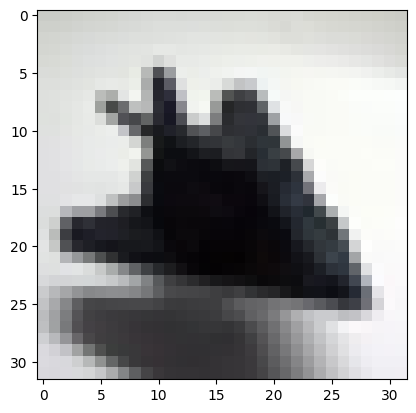

In [13]:
show_example(*dataset[0])

Label:  airplane (0)


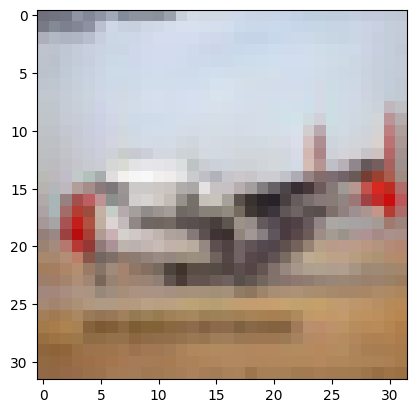

In [14]:
show_example(*dataset[1099])

## Training and Validation Datasets

In [16]:
def split_indices(n, val_pct=0.1, seed=90):
    #Determine validation set size
    n_val = int(val_pct*n)
    #Set the random seed (for reproductivity)
    np.random.seed(seed)
    #Create a random permutation of 0 to n-1
    idxs = np.random.permutation(n)
    return idxs[n_val:], idxs[:n_val]

In [17]:
val_pct = 0.2
rand_seed = 42

train_indices, val_indices = split_indices(len(dataset), val_pct, rand_seed)
print(len(train_indices), len(val_indices))
print("Sample validation indices: ", val_indices[:10])

40000 10000
Sample validation indices:  [33553  9427   199 12447 39489 42724 10822 49498  4144 36958]


In [18]:
batch_size = 100

#Training sampler and data loader
train_sampler = SubsetRandomSampler(train_indices)
train_dl = DataLoader(dataset,
                      batch_size,
                      sampler=train_sampler)

#Validation sampler and data loader
val_sampler = SubsetRandomSampler(val_indices)
val_dl = DataLoader(dataset,
                    batch_size,
                    sampler=val_sampler)

In [19]:
def show_batch(dl):
    for images, labels in dl:
        fig, ax = plt.subplots(figsize=(10,10))
        ax.set_xticks([]); ax.set_yticks([])
        ax.imshow(make_grid(images, nrow=16).permute(1,2,0))
        break

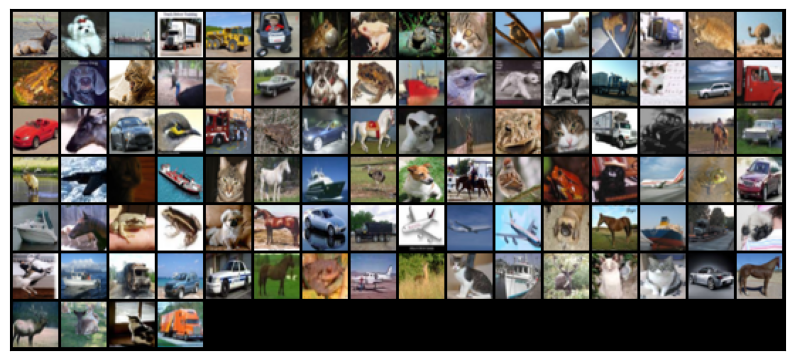

In [20]:
show_batch(train_dl)

## Defining the Model (CNN)

In [40]:
simple_model = nn.Sequential(
    nn.Conv2d(3, 8, kernel_size=3, stride=1, padding=1),
    nn.MaxPool2d(2, 2)
)

In [42]:
for img, lable in train_dl:
    print("image.shape: ", img.shape)
    out = simple_model(img)
    print("out.shape: ", out.shape)
    break

image.shape:  torch.Size([100, 3, 32, 32])
out.shape:  torch.Size([100, 8, 16, 16])


In [48]:
model = nn.Sequential(
    nn.Conv2d(3, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), #Output: bs x 16 x 16 x16

    nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), #Output: bs x 16 x 8 x 8

    nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), #Output: bs x 16 x 4 x 4

    nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), #Output: bs x 16 x 2 x 2

    nn.Conv2d(16, 16, kernel_size=3, stride=1, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(2, 2), #Output: bs x 16 x 1 x 1

    nn.Flatten(), # Output: bs x 16
    nn.Linear(16, 10), # Ouput: bs x 10
)

In [54]:
for img, lable in train_dl:
    print("image.shape: ", img.shape)
    out = simple_model(img)
    print("out.shape: ", out.shape)
    print("out: ", out[0])
    break

image.shape:  torch.Size([100, 3, 32, 32])
out.shape:  torch.Size([100, 8, 16, 16])
out:  tensor([[[-1.1053e-01, -8.3366e-02, -1.0691e-01,  ..., -9.1055e-02,
          -6.4175e-02, -2.8221e-02],
         [-1.9459e-01, -1.3108e-01, -1.4798e-01,  ..., -2.3116e-01,
          -6.2731e-02, -1.1208e-01],
         [-1.9134e-01, -1.8562e-01, -1.3684e-01,  ..., -2.2377e-01,
          -5.8209e-02, -7.8908e-02],
         ...,
         [-2.3525e-01, -2.0670e-01, -2.1425e-01,  ..., -1.8869e-01,
          -1.9303e-01, -5.5478e-02],
         [-2.4175e-01, -2.4317e-01, -2.0293e-01,  ..., -1.8220e-01,
          -6.6550e-02, -3.1567e-02],
         [-1.8218e-01, -2.1069e-01, -1.9664e-01,  ..., -2.4487e-01,
          -7.9539e-02, -1.4172e-01]],

        [[ 2.6669e-02,  5.0199e-03,  1.9986e-02,  ...,  3.9178e-02,
           3.7734e-03,  2.6961e-02],
         [ 1.9635e-02,  2.7080e-02,  6.3490e-03,  ...,  1.0970e-02,
          -5.7802e-02, -4.0448e-02],
         [ 1.5683e-02, -3.2062e-03,  1.5971e-02,  ...,

In [56]:
def get_default_device():
    """Pick GPU if available, else CPU"""
    if torch.cuda.is_available():
        return torch.device('cuda')
    else:
        return torch.device('cpu')
    
def to_device(data, device):
    """Move tensor(s) to chosen device"""
    if isinstance(data, (list,tuple)):
        return [to_device(x, device) for x in data]
    return data.to(device, non_blocking=True)

class DeviceDataLoader():
    """Wrap a dataloader to move data to a device"""
    def __init__(self, dl, device):
        self.dl = dl
        self.device = device
        
    def __iter__(self):
        """Yield a batch of data after moving it to device"""
        for b in self.dl: 
            yield to_device(b, self.device)

    def __len__(self):
        """Number of batches"""
        return len(self.dl)

In [58]:
device = get_default_device()
device

device(type='cpu')

In [77]:
train_dl = DeviceDataLoader(train_dl, device)
valid_dl = DeviceDataLoader(val_dl, device)
to_device(model, device);

## Train the Model

In [81]:
def loss_batch(model, loss_func, xb, yb, opt=None, metric=None):
    #Generate predictions
    preds = model(xb)
    #Calculate the loss
    loss = loss_func(preds, yb)

    if opt is not None:
        #Compute gradients
        loss.backward()
        #Update the parameters
        opt.step()
        #Reset gradients
        opt.zero_grad()

    metric_result = None
    if metric is not None:
        #Compute the metric
        metric_result = metric(preds, yb)

    return loss.item(), len(xb), metric_result

In [85]:
def evaluate(model, loss_fn, valid_dl, metric=None):
    with torch.no_grad():
        # Pass each batch through the model
        results = [loss_batch(model, loss_fn, xb, yb, metric=metric)
                   for xb, yb in valid_dl]
        # Separate losses, counts and metrics
        losses, nums, metrics = zip(*results)
        # Total size of the dataset
        total = np.sum(nums)
        # Avg. loss across batches
        avg_loss = np.sum(np.multiply(losses, nums)) / total
        avg_metric = None
        if metric is not None:
            # Avg. of metric across batches
            avg_metric = np.sum(np.multiply(metrics, nums)) / total
        return avg_loss, total, avg_metric

In [117]:
def fit(epochs, model, loss_fn, train_dl, valid_dl, opt=None, lr=None, metric=None):
    train_losses, valid_losses, valid_metrics = [], [], []

    # Instantiate the optimizer
    if opt is not None: opt_fn = torch.optim.SGD
    opt = opt_fn(model.parameters(), lr=lr)

    for epoch in range(epochs):
        #Training
        model.train()
        for xb, yb in train_dl:
            train_loss,_,_ = loss_batch(model, loss_fn, xb, yb, opt)

    #Evaluation
    model.eval()
    result = evaluate(model, loss_fn, valid_dl, metric)
    val_loss, total, val_metric = result

    #Record the loss & metric
    train_losses.append(train_loss)
    valid_losses.append(val_loss)
    valid_metrics.append(val_metric)

    #Print progress
    if metric is None:
        print("Epoch [{}/{}], train_loss: {:.4f}, val_loss: {:.4f}".format(epoch+1, epochs, train_loss, val_loss))
    else:
        print("Epoch [{}/{}], train_loss: {:.4f}, val_loss: {:.4f}, val_{}: {:.4f}".format(epoch+1, epochs, train_loss, val_loss, metric.__name__, val_metric))
    return train_losses, valid_losses, valid_metrics

In [71]:
def accuracy(outputs, labels):
    _, preds = torch.max(outputs, dim=1)
    return torch.sum(preds == labels).item() / len(preds)

In [87]:
val_loss, _, val_acc = evaluate(model, F.cross_entropy, valid_dl, metric=accuracy)
print("Loss: {:.4f}, Accuracy: {:.4f}".format(val_loss, val_acc))

Loss: 2.3054, Accuracy: 0.0995


In [89]:
num_epochs = 10
opt_fn = torch.optim.Adam
lr = 0.005

In [99]:
history = fit(num_epochs, model, F.cross_entropy, train_dl, valid_dl, opt_fn, lr, accuracy)
train_losses, val_losses, val_metrics = history

Epoch [10/10], train_loss: 2.3030, val_loss: 2.3024, val_accuracy; 0.0957


## Testing on Real Data

In [120]:
test_dataset = ImageFolder(data_dir+'/test', transform=ToTensor())

In [130]:
def predict_image(img, model):
    #COnvert to batch of 1
    xb = img.unsqueeze(0)
    #Get the prediction from model
    yb = model(xb)
    #Pick index with the highest probability
    _, preds = torch.max(yb, dim=1)
    #Retrieve the class label
    return dataset.classes[preds[0].item()]

Label: airplane , Predicted: ship


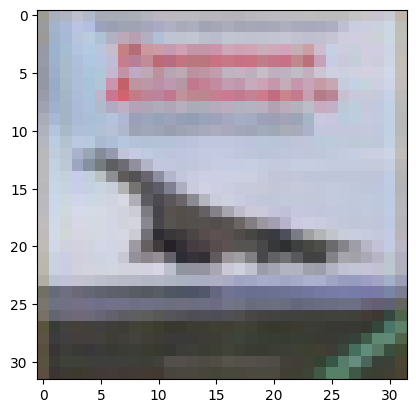

In [132]:
img, label = test_dataset[0]
plt.imshow(img.permute(1, 2, 0))
print("Label:", dataset.classes[label], ", Predicted:", predict_image(img, model))

In [ ]:
img, label = test_dataset[10]
plt.imshow(img.permute(1, 2, 0))
print("Label:", dataset.classes[label], ", Predicted:", predict_image(img, model))